# Objetivo 3 — CNN Clasica: ResNet-18 (Linea Base)
Fine-tuning completo desde ImageNet.  
Capa fc adaptada: `512 → 4 → n_classes`  
El cuello de botella de **4 features** iguala la dimension de salida de los 4 qubits de los modelos HQCNN, haciendo la comparacion justa.
**Datasets:** etl_output/chest_xray · etl_output/lung_cancer

## 0 · Instalacion de dependencias

In [4]:
import subprocess, sys
pkgs = [
    'torch torchvision --index-url https://download.pytorch.org/whl/cu118',
    'scikit-learn matplotlib seaborn tqdm',
]
for pkg in pkgs:
    subprocess.run([sys.executable,'-m','pip','install','-q']+pkg.split(), check=False)
print('OK')


OK


## 1 · Imports y seed global

In [5]:
import os, random, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, WeightedRandomSampler
from tqdm.notebook import tqdm
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device: ', DEVICE)
if torch.cuda.is_available(): print('GPU:', torch.cuda.get_device_name(0))


PyTorch: 2.12.0+cpu
Device:  cpu


## 2 · Rutas y DataLoaders

In [6]:
BASE_DIR  = Path(os.getcwd())
CHEST_OUT = BASE_DIR / 'etl_output' / 'chest_xray'
LUNG_OUT  = BASE_DIR / 'etl_output' / 'lung_cancer'
BATCH_SIZE = 32
IMG_SIZE   = (128, 128)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_train = T.Compose([
    T.Resize(IMG_SIZE), T.Grayscale(num_output_channels=3),
    T.RandomRotation(10), T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.15),
    T.RandomAffine(degrees=0, scale=(0.90, 1.10)),
    T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
transform_eval = T.Compose([
    T.Resize(IMG_SIZE), T.Grayscale(num_output_channels=3),
    T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def make_loaders(root, weighted=False):
    root = Path(root)
    ds_tr = ImageFolder(root/'train', transform=transform_train)
    ds_va = ImageFolder(root/'val',   transform=transform_eval)
    ds_te = ImageFolder(root/'test',  transform=transform_eval)
    if weighted:
        tgts = torch.tensor(ds_tr.targets)
        sw   = (1.0/torch.bincount(tgts).float())[tgts]
        loader_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE,
                               sampler=WeightedRandomSampler(sw,len(sw),True),
                               num_workers=2, pin_memory=True)
    else:
        loader_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=2, pin_memory=True)
    loader_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    loader_te = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    return loader_tr, loader_va, loader_te, ds_tr.class_to_idx

chest_train_loader, chest_val_loader, chest_test_loader, chest_classes = make_loaders(CHEST_OUT)
lung_train_loader,  lung_val_loader,  lung_test_loader,  lung_classes  = make_loaders(LUNG_OUT, weighted=True)
N_CLASSES_CHEST = len(chest_classes)
N_CLASSES_LUNG  = len(lung_classes)

ds_lung_tr = ImageFolder(LUNG_OUT/'train')
tgts = torch.tensor(ds_lung_tr.targets)
lung_cw = (1.0/torch.bincount(tgts).float())
lung_cw = (lung_cw/lung_cw.sum()).to(DEVICE)

print('Chest:', chest_classes)
print('Lung: ', lung_classes)
print('Lung class weights:', lung_cw)


Chest: {'NORMAL': 0, 'PNEUMONIA': 1}
Lung:  {'Benign': 0, 'Malignant': 1, 'Normal': 2}
Lung class weights: tensor([0.6654, 0.1426, 0.1921])


## 3 · Arquitectura ResNet-18 adaptada
Se reemplaza la capa `fc` original (`512 → 1000`) por:
```
Linear(512, 4)  →  ReLU  →  Linear(4, n_classes)
```
El cuello de **4 features** iguala la dimension de salida de los 4 qubits (4 valores `<Z>`) de los modelos HQCNN.

In [7]:
N_QUANTUM_DIM = 4   # mismo que N_QUBITS en los modelos HQCNN

def build_resnet18(n_classes: int) -> nn.Module:
    """
    ResNet-18 preentrenado en ImageNet, fine-tuning completo.
    fc: 512 -> 4 -> n_classes
    El bottleneck de 4 features iguala la dimension de salida
    de los 4 qubits de los modelos HQCNN (comparacion justa).
    """
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features  # 512
    model.fc = nn.Sequential(
        nn.Linear(in_features, N_QUANTUM_DIM),
        nn.ReLU(),
        nn.Linear(N_QUANTUM_DIM, n_classes),
    )
    return model

# Verificacion de shapes
with torch.no_grad():
    m2 = build_resnet18(2)
    m3 = build_resnet18(3)
    x  = torch.randn(2, 3, 128, 128)
    print('ResNet-18 output (n=2):', m2(x).shape)
    print('ResNet-18 output (n=3):', m3(x).shape)
    p2 = sum(p.numel() for p in m2.parameters() if p.requires_grad)
    print(f'Parametros entrenables: {p2:,}')
    print()
    print('Capa fc:')
    print(m2.fc)


ResNet-18 output (n=2): torch.Size([2, 2])
ResNet-18 output (n=3): torch.Size([2, 3])
Parametros entrenables: 11,178,574

Capa fc:
Sequential(
  (0): Linear(in_features=512, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=2, bias=True)
)


## 4 · Diagrama de la capa fc

In [8]:
print('Arquitectura fc (ResNet-18 adaptada):')
print()
print('  avgpool  →  flatten(512)  →  Linear(512,4)  →  ReLU  →  Linear(4, n_classes)')
print()
print('       ↑ backbone ResNet-18 (congelado/fino)      ↑ comparable a 4 expval <Z> HQCNN')
print()
print('Modelos HQCNN:  backbone → pre_quantum(N_QUBITS=4) → q_layer(4 expval) → Linear(4, n_classes)')
print('ResNet-18:      backbone →                           fc(512→4)          → Linear(4, n_classes)')


Arquitectura fc (ResNet-18 adaptada):

  avgpool  →  flatten(512)  →  Linear(512,4)  →  ReLU  →  Linear(4, n_classes)

       ↑ backbone ResNet-18 (congelado/fino)      ↑ comparable a 4 expval <Z> HQCNN

Modelos HQCNN:  backbone → pre_quantum(N_QUBITS=4) → q_layer(4 expval) → Linear(4, n_classes)
ResNet-18:      backbone →                           fc(512→4)          → Linear(4, n_classes)


## 5 · Loop de entrenamiento
Protocolo identico al de los modelos HQCNN: Adam, lr 1e-3→1e-4 (epoch 10), early stopping patience=5 sobre F1-macro.

In [9]:
def train_model(model, train_loader, val_loader, class_weights=None,
                max_epochs=50, patience=5, save_path=None):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10], gamma=0.1)
    history = {'train_loss':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}
    best_f1, no_improve = 0.0, 0

    for epoch in range(1, max_epochs+1):
        model.train()
        total_loss = 0.0
        for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch}/{max_epochs}', leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * imgs.size(0)
        scheduler.step()
        avg_tr = total_loss / len(train_loader.dataset)

        model.eval()
        val_loss, preds, labs = 0.0, [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits = model(imgs)
                val_loss += criterion(logits, labels).item() * imgs.size(0)
                preds.extend(logits.argmax(1).cpu().numpy())
                labs.extend(labels.cpu().numpy())
        avg_va  = val_loss / len(val_loader.dataset)
        val_acc = sum(p==l for p,l in zip(preds,labs)) / len(labs)
        val_f1  = f1_score(labs, preds, average='macro', zero_division=0)

        history['train_loss'].append(avg_tr)
        history['val_loss'].append(avg_va)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        print(f'Epoch {epoch:3d} | train={avg_tr:.4f} | val={avg_va:.4f} | acc={val_acc:.4f} | F1={val_f1:.4f}')

        if val_f1 > best_f1:
            best_f1, no_improve = val_f1, 0
            if save_path: torch.save(model.state_dict(), save_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping en epoca {epoch}')
                break
    return history


def evaluate_model(model, test_loader, class_names, model_name):
    model = model.to(DEVICE).eval()
    preds, labs, probs = [], [], []
    t0 = time.time()
    with torch.no_grad():
        for imgs, labels in test_loader:
            logits = model(imgs.to(DEVICE))
            probs.extend(torch.softmax(logits,1).cpu().numpy())
            preds.extend(logits.argmax(1).cpu().numpy())
            labs.extend(labels.numpy())
    elapsed = time.time() - t0
    inf_ms  = elapsed / len(labs) * 1000
    acc     = accuracy_score(labs, preds)
    f1_mac  = f1_score(labs, preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(labs, probs, multi_class='ovr', average='macro') \
              if len(class_names)>2 else roc_auc_score(labs, [p[1] for p in probs])
    except Exception:
        auc = float('nan')
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f'\n=== {model_name} ===')
    print(f'  Accuracy : {acc:.4f}  |  F1-macro : {f1_mac:.4f}  |  AUC : {auc:.4f}')
    print(f'  Inf/img  : {inf_ms:.3f} ms  |  Params : {params:,}')
    print()
    print(classification_report(labs, preds, target_names=class_names, zero_division=0))

    cm = confusion_matrix(labs, preds)
    plt.figure(figsize=(max(4,len(class_names)*2), max(3,len(class_names)*1.5)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('Real'); plt.xlabel('Predicho')
    plt.tight_layout(); plt.show()
    return {'acc':acc,'f1':f1_mac,'auc':auc,'inf_ms':inf_ms,'params':params}


def plot_history(history, model_name):
    fig, axes = plt.subplots(1,2,figsize=(12,4))
    fig.suptitle(f'Curvas — {model_name}', fontweight='bold')
    axes[0].plot(history['train_loss'], label='train')
    axes[0].plot(history['val_loss'],   label='val')
    axes[0].set_title('Loss'); axes[0].legend()
    axes[1].plot(history['val_acc'], label='acc')
    axes[1].plot(history['val_f1'],  label='F1-macro')
    axes[1].set_title('Val Accuracy / F1'); axes[1].legend()
    plt.tight_layout(); plt.show()

print('Funciones definidas: train_model, evaluate_model, plot_history')


Funciones definidas: train_model, evaluate_model, plot_history


## 6 · Ejecucion — Chest X-Ray (Pneumonia)

Epoch 1/50:   0%|          | 0/129 [00:00<?, ?it/s]

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1 | train=0.2119 | val=0.1563 | acc=0.9396 | F1=0.9251


Epoch 2/50:   0%|          | 0/129 [00:00<?, ?it/s]

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  14 | train=0.0595 | val=0.0766 | acc=0.9704 | F1=0.9629


Epoch 15/50:   0%|          | 0/129 [00:00<?, ?it/s]

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  15 | train=0.0548 | val=0.0826 | acc=0.9681 | F1=0.9606
Early stopping en epoca 15


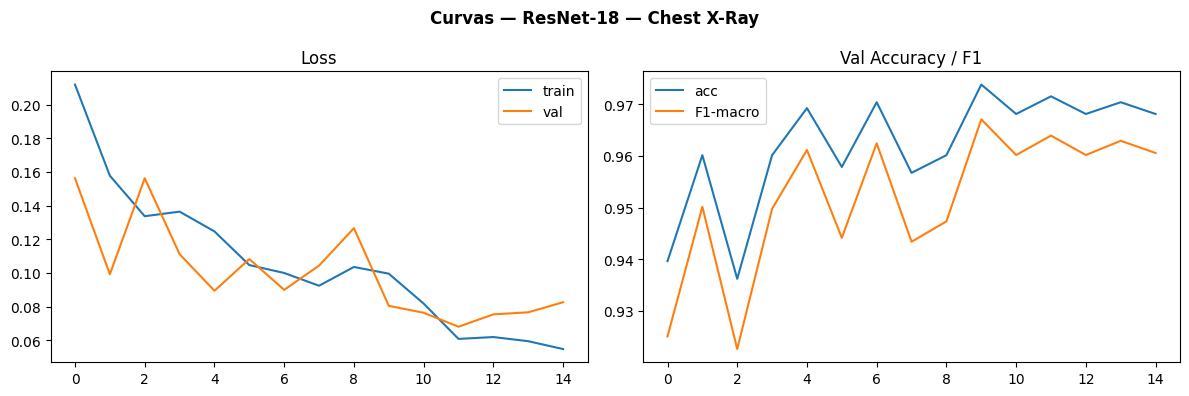

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



=== ResNet-18 Chest ===
  Accuracy : 0.9659  |  F1-macro : 0.9575  |  AUC : 0.9931
  Inf/img  : 24.027 ms  |  Params : 11,178,574

              precision    recall  f1-score   support

      NORMAL       0.92      0.96      0.94       238
   PNEUMONIA       0.99      0.97      0.98       641

    accuracy                           0.97       879
   macro avg       0.95      0.96      0.96       879
weighted avg       0.97      0.97      0.97       879



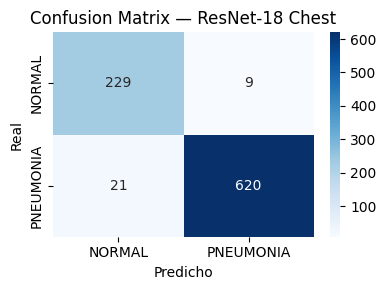

In [7]:
CHEST_NAMES = ['NORMAL', 'PNEUMONIA']
SAVE_DIR = BASE_DIR / 'checkpoints' / 'chest'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

model_chest = build_resnet18(N_CLASSES_CHEST).to(DEVICE)

history_chest = train_model(
    model_chest, chest_train_loader, chest_val_loader,
    class_weights=None, max_epochs=50, patience=5,
    save_path=str(SAVE_DIR / 'resnet18_best.pt')
)
plot_history(history_chest, 'ResNet-18 — Chest X-Ray')

model_chest.load_state_dict(torch.load(SAVE_DIR / 'resnet18_best.pt'))
results_chest = evaluate_model(model_chest, chest_test_loader, CHEST_NAMES, 'ResNet-18 Chest')


## 7 · Ejecucion — IQ-OTH/NCCD Lung Cancer

Epoch 1/50:   0%|          | 0/24 [00:00<?, ?it/s]

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1 | train=0.7333 | val=9.5576 | acc=0.1152 | F1=0.0738


Epoch 2/50:   0%|          | 0/24 [00:00<?, ?it/s]

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  24 | train=0.0382 | val=0.2664 | acc=0.9515 | F1=0.9164


Epoch 25/50:   0%|          | 0/24 [00:00<?, ?it/s]

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  25 | train=0.0504 | val=0.2021 | acc=0.9455 | F1=0.9090
Early stopping en epoca 25


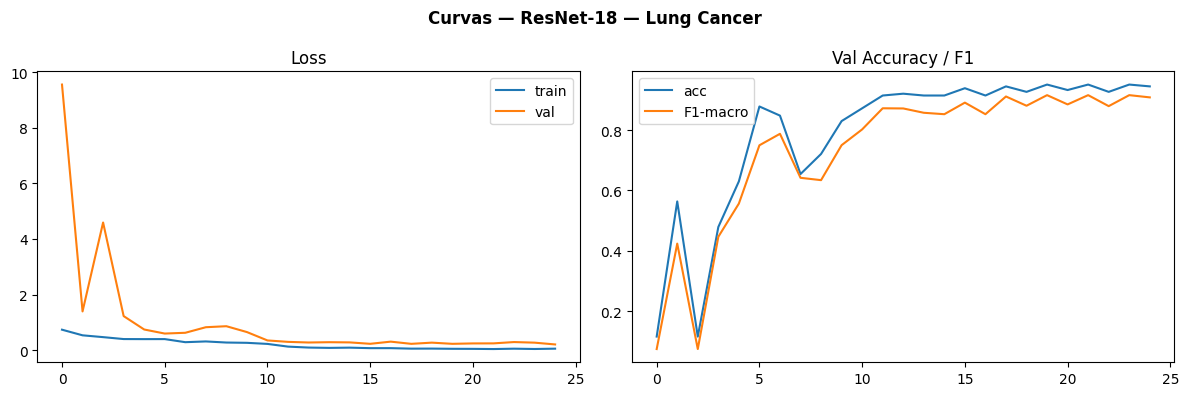

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



=== ResNet-18 Lung ===
  Accuracy : 0.9697  |  F1-macro : 0.9457  |  AUC : 0.9857
  Inf/img  : 47.256 ms  |  Params : 11,178,579

              precision    recall  f1-score   support

      Benign       0.94      0.83      0.88        18
   Malignant       1.00      0.99      0.99        85
      Normal       0.94      0.98      0.96        62

    accuracy                           0.97       165
   macro avg       0.96      0.94      0.95       165
weighted avg       0.97      0.97      0.97       165



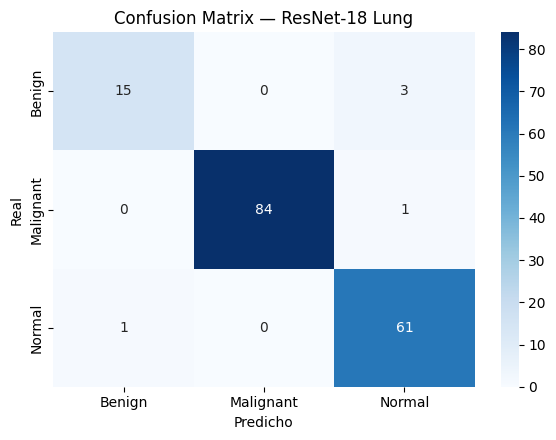

In [10]:
LUNG_NAMES = ['Benign', 'Malignant', 'Normal']
SAVE_DIR_L = BASE_DIR / 'checkpoints' / 'lung'
SAVE_DIR_L.mkdir(parents=True, exist_ok=True)

model_lung = build_resnet18(N_CLASSES_LUNG).to(DEVICE)

history_lung = train_model(
    model_lung, lung_train_loader, lung_val_loader,
    class_weights=lung_cw, max_epochs=50, patience=5,
    save_path=str(SAVE_DIR_L / 'resnet18_best.pt')
)
plot_history(history_lung, 'ResNet-18 — Lung Cancer')

model_lung.load_state_dict(torch.load(SAVE_DIR_L / 'resnet18_best.pt'))
results_lung = evaluate_model(model_lung, lung_test_loader, LUNG_NAMES, 'ResNet-18 Lung')
